In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats.distributions as dist
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

In [4]:
marketing_ab_df = pd.read_csv('marketing_AB.csv', index_col=0)
marketing_ab_df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [4]:
marketing_ab_df.shape

(588101, 6)

In [5]:
marketing_ab_df = marketing_ab_df.rename(columns = {'user id':'user_id','test group':'test_group','total ads':'total_ads','most ads day': 'most_ads_day','most ads hour':'most_ads_hour'}) 
marketing_ab_df.head()

,user_id,test_group,converted,total_ads,most_ads_day,most_ads_hour
0,1069124,ad,False,130,Monday,20
1,1119715,ad,False,93,Tuesday,22
2,1144181,ad,False,21,Tuesday,18
3,1435133,ad,False,355,Tuesday,10
4,1015700,ad,False,276,Friday,14


In [6]:
marketing_ab_df.isna().sum()

user_id          0
test_group       0
converted        0
total_ads        0
most_ads_day     0
most_ads_hour    0
dtype: int64

In [7]:
marketing_ab_df.duplicated().sum()

0

In [8]:
marketing_ab_df.dtypes

user_id           int64
test_group       object
converted          bool
total_ads         int64
most_ads_day     object
most_ads_hour     int64
dtype: object

In [9]:
marketing_ab_df.describe()

,user_id,total_ads,most_ads_hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [10]:
correlation = marketing_ab_df[['user_id', 'total_ads', 'most_ads_hour']]

<Axes: >

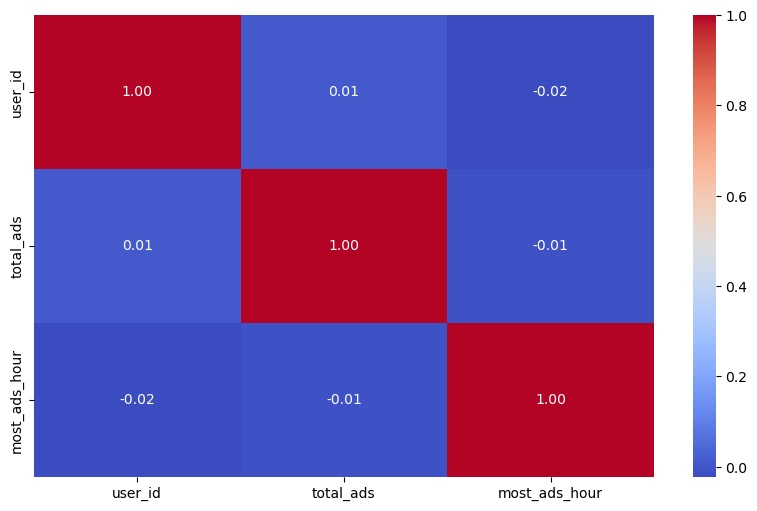

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation.corr(), annot=True, cmap='coolwarm', fmt=".2f")

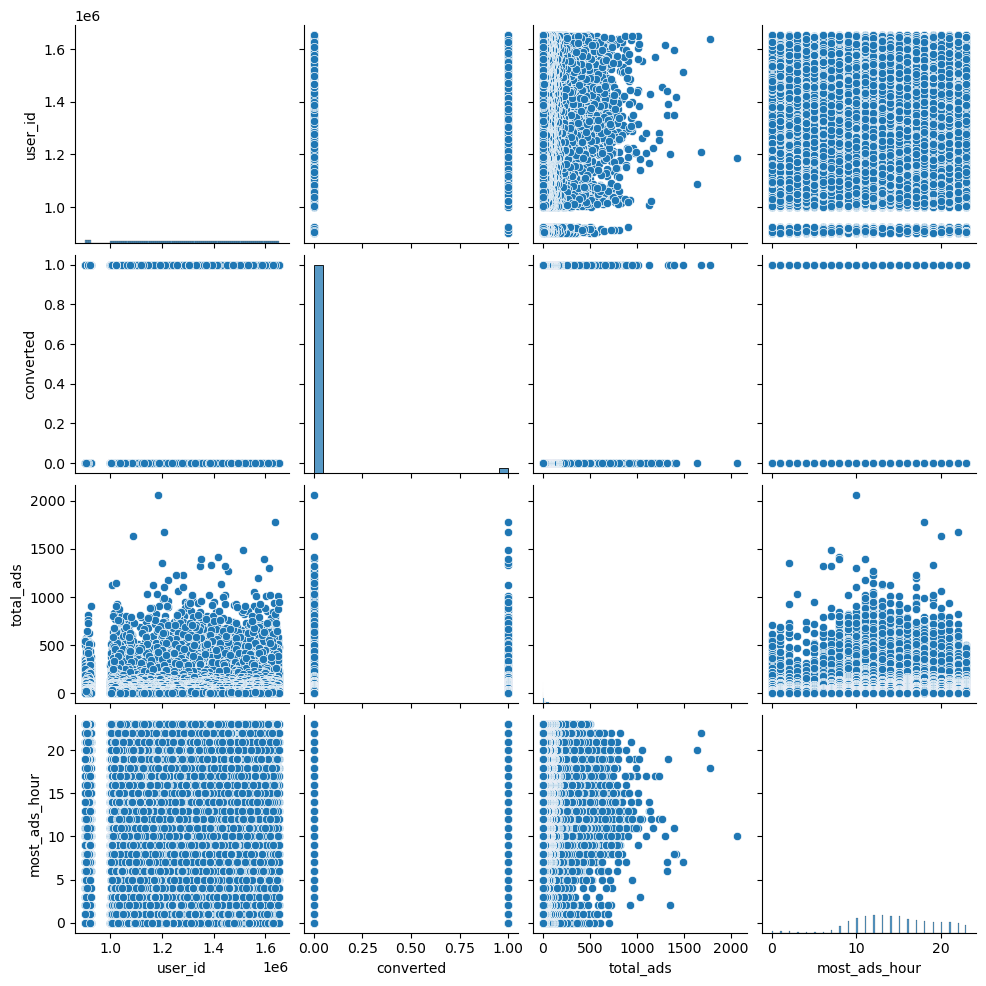

In [19]:
sns.pairplot(data = marketing_ab_df)

<Axes: xlabel='most_ads_hour', ylabel='Count'>

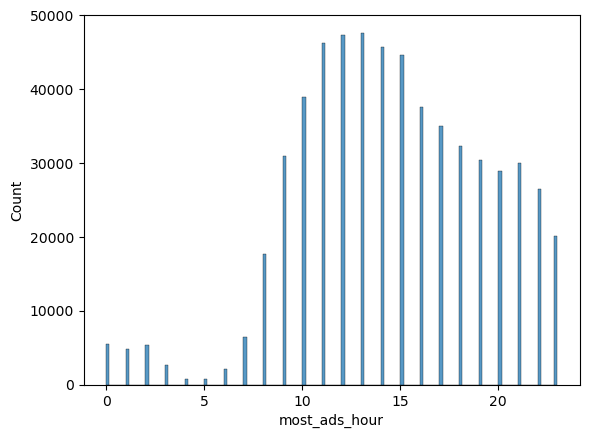

In [23]:
sns.histplot(data = marketing_ab_df, x = 'most_ads_hour')

In [25]:
marketing_ab_df.test_group.value_counts()

test_group
ad     564577
psa     23524
Name: count, dtype: int64

In [12]:
marketing_ab_df.test_group.value_counts(normalize=True) * 100

test_group
ad     96.000007
psa     3.999993
Name: proportion, dtype: float64

<Axes: xlabel='test_group', ylabel='count'>

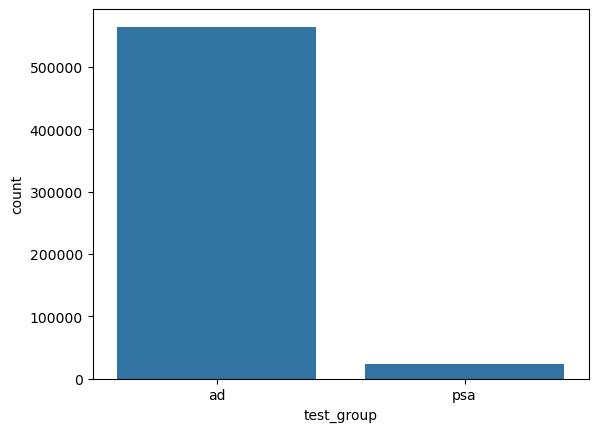

In [13]:
sns.countplot(data = marketing_ab_df, x = 'test_group')

C:\Users\Stephen Williams\AppData\Local\Temp\ipykernel_17464\2722487790.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="test group", y="converted", data=marketing_ab_df, ci=None)


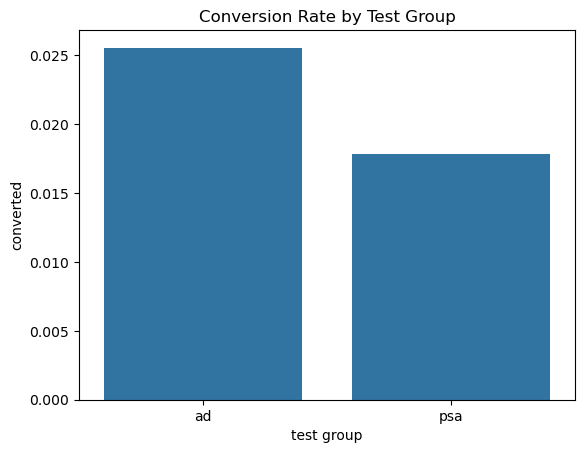

In [4]:
sns.barplot(x="test group", y="converted", data=marketing_ab_df, ci=None)
plt.title("Conversion Rate by Test Group")
plt.show()



In [15]:
success = marketing_ab_df.groupby("test_group")["converted"].apply(lambda x: (x == True).sum())
print(success)

test_group
ad     14423
psa      420
Name: converted, dtype: int64


In [16]:
marketing_ab_df['converted'].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [17]:
nobs = marketing_ab_df.groupby("test_group")["converted"].count()
print(nobs)

test_group
ad     564577
psa     23524
Name: converted, dtype: int64


In [18]:
successes = marketing_ab_df.groupby("test_group")["converted"].sum()
print(successes)

test_group
ad     14423
psa      420
Name: converted, dtype: int64


In [19]:
def z_test_2_sample_proportions(x1, x2, n1, n2, two_tailed=True):
    '''
    Calculate the test statistic for a z-test on 2 proportions from independent samples
    x1, x2: number of successes in group 1 and 2
    n1, n2: total number of observations in group 1 and 2
    Returns: test statistic (z), and p-value 
    '''
    avg_p = (x1 + x2) / (n1 + n2)
    z_val = (x1/n1 - x2/n2) / np.sqrt(avg_p * (1-avg_p) * (1/n1 + 1/n2))
    z_prob = dist.norm.cdf(-np.abs(z_val))

    if two_tailed:
        return z_val, 2*z_prob

    else:
        return z_val, z_prob

In [20]:
z_test_2_sample_proportions(successes['ad'], successes['psa'], nobs['ad'], nobs['psa'],two_tailed=True)

(7.3700781265454145, 1.7052807161559727e-13)

In [8]:
success_arr = np.array([successes.loc['psa'], successes.loc['ad']])
nobs_arr = np.array([nobs.loc['psa'], nobs.loc['ad']])

z, p = proportions_ztest(success_arr, nobs_arr, alternative='two-sided')
print(f"Z-test statistic: {z:.4f}, p-value: {p:.4f}")

Z-test statistic: -7.3701, p-value: 0.0000


In [21]:
def confidence_interval(x1, x2, n1, n2):
    p1 = x1 / n1
    p2 = x2 / n2
    diff = p1 - p2
    se = np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    z_score = dist.norm.ppf(0.975)  # 95% confidence
    margin = z_score * se
    return diff - margin, diff + margin

In [22]:
confidence_interval(successes['ad'], successes['psa'], nobs['ad'], nobs['psa'])

(0.0059509324316110055, 0.009433973952792028)

In [30]:
new_df = marketing_ab_df[['most_ads_hour','total_ads']]
print(new_df)

        most_ads_hour  total_ads
0                  20        130
1                  22         93
2                  18         21
3                  10        355
4                  14        276
...               ...        ...
588096             23          1
588097             23          1
588098             23          3
588099             23          1
588100             23          1

[588101 rows x 2 columns]


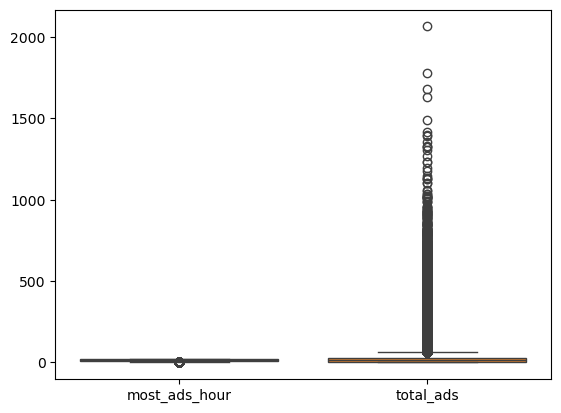

In [31]:
sns.boxplot(data=new_df)
plt.show()

In [33]:
new_df.describe()

,most_ads_hour,total_ads
count,588101.000000,588101.000000
mean,14.469061,24.820876
std,4.834634,43.715181
min,0.000000,1.000000
25%,11.000000,4.000000
50%,14.000000,13.000000
75%,18.000000,27.000000
max,23.000000,2065.000000


In [8]:
table = pd.crosstab(marketing_ab_df['most_ads_day'], marketing_ab_df['converted'])
table


converted,False,True
most_ads_day,,
Friday,90551,2057
Monday,84216,2857
Saturday,79941,1719
Sunday,83301,2090
Thursday,81192,1790
Tuesday,75167,2312
Wednesday,78890,2018


In [9]:
result = chi2_contingency(table)
result

Chi2ContingencyResult(statistic=410.0478857936585, pvalue=1.932184379244731e-85, dof=6, expected_freq=array([[90270.67946492,  2337.32053508],
       [84875.37656627,  2197.62343373],
       [79598.99452645,  2061.00547355],
       [83235.82833221,  2155.17166779],
       [80887.62875084,  2094.37124916],
       [75523.51820861,  1955.48179139],
       [78865.9741507 ,  2042.0258493 ]]))

## Logistic regression using total ads and most ads day

The target is `converted`. The predictors are `total_ads` and `most_ads_day`; weekday values are one-hot encoded, with Friday used as the reference category.

In [ ]:
import statsmodels.formula.api as smf

statsmodels_data = marketing_ab_df[['most_ads_day', 'converted']].copy()
statsmodels_data['converted'] = statsmodels_data['converted'].astype(int)
weekday_model = smf.logit(
    "converted ~ C(most_ads_day, Treatment(reference='Sunday'))",
    data=statsmodels_data
).fit(disp=False)

print(weekday_model.summary())

C:\Users\Stephen Williams\AppData\Local\Temp\ipykernel_30180\1793229356.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  statsmodels_data['converted'] = statsmodels_data['converted'].astype(int)


                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:               588101
Model:                          Logit   Df Residuals:                   588094
Method:                           MLE   Df Model:                            6
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                0.002861
Time:                        15:50:39   Log-Likelihood:                -69069.
converged:                       True   LL-Null:                       -69267.
Covariance Type:            nonrobust   LLR p-value:                 1.691e-82
                                                                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------------------------------
Intercept                                                      -3.6853      0.022   -166.404      0.000      -3.

In [10]:
odds_ratios = pd.DataFrame({
    'odds_ratio': np.exp(weekday_model.params),
    'ci_lower': np.exp(weekday_model.conf_int()[0]),
    'ci_upper': np.exp(weekday_model.conf_int()[1]),
    'p_value': weekday_model.pvalues
})

odds_ratios

,odds_ratio,ci_lower,ci_upper,p_value
Intercept,0.022716,0.021745,0.023731,0.000000e+00
"C(most_ads_day, Treatment(reference='Friday'))[T.Monday]",1.493395,1.410022,1.581697,1.281592e-42
"C(most_ads_day, Treatment(reference='Friday'))[T.Saturday]",0.946597,0.887246,1.009918,9.666866e-02
"C(most_ads_day, Treatment(reference='Friday'))[T.Sunday]",1.104473,1.038495,1.174643,1.567637e-03
"C(most_ads_day, Treatment(reference='Friday'))[T.Thursday]",0.970507,0.910289,1.034709,3.596820e-01
"C(most_ads_day, Treatment(reference='Friday'))[T.Tuesday]",1.354003,1.274912,1.438000,5.668860e-23
"C(most_ads_day, Treatment(reference='Friday'))[T.Wednesday]",1.126051,1.058201,1.198252,1.810707e-04


Classification threshold: 0.025
Predicted class counts:
0    84722
1    32899
Name: count, dtype: int64
Probability range: 0.0209 to 0.0328
Confusion matrix:


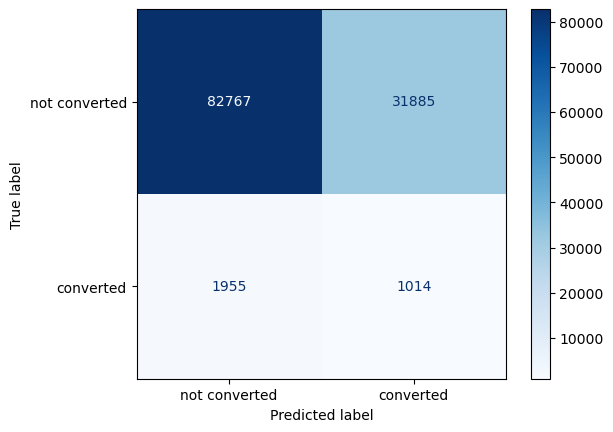


Classification report:
               precision    recall  f1-score   support

not converted       0.98      0.72      0.83    114652
    converted       0.03      0.34      0.06      2969

     accuracy                           0.71    117621
    macro avg       0.50      0.53      0.44    117621
 weighted avg       0.95      0.71      0.81    117621



In [23]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    statsmodels_data[['most_ads_day']],
    statsmodels_data['converted'],
    test_size=0.20,
    random_state=42,
    stratify=statsmodels_data['converted']
)

weekday_model_train = smf.logit(
    "converted ~ C(most_ads_day, Treatment(reference='Sunday'))",
    data=pd.concat([X_train, y_train], axis=1)
).fit(disp=False)

test_probabilities = weekday_model_train.predict(X_test)
threshold = 0.025
test_predictions = (test_probabilities >= threshold).astype(int)
cm = confusion_matrix(y_test, test_predictions)

print(f'Classification threshold: {threshold}')
print(f'Predicted class counts:\n{pd.Series(test_predictions).value_counts().sort_index()}')
print(f'Probability range: {test_probabilities.min():.4f} to {test_probabilities.max():.4f}')
print('Confusion matrix:')
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['not converted', 'converted']
).plot(cmap=plt.cm.Blues)
plt.show()

print('\nClassification report:')
print(classification_report(
    y_test,
    test_predictions,
    target_names=['not converted', 'converted'],
    zero_division=0
))